# **ЛАБОРАТОРНА РОБОТА 4**
## Support Vector Machine (SVM)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from time import time

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

## **1. Завантаження та підготовка даних (лаб2)**
### Посилання на набір даних [https://www.kaggle.com/datasets/muratkokludataset/dry-bean-dataset](https://www.kaggle.com/datasets/muratkokludataset/dry-bean-dataset)

In [2]:
df = pd.read_csv("Dry_Bean_Dataset.csv")
print("Розмір датасету:", df.shape)

df

Розмір датасету: (13611, 17)


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13606,42097,759.696,288.721612,185.944705,1.552728,0.765002,42508,231.515799,0.714574,0.990331,0.916603,0.801865,0.006858,0.001749,0.642988,0.998385,DERMASON
13607,42101,757.499,281.576392,190.713136,1.476439,0.735702,42494,231.526798,0.799943,0.990752,0.922015,0.822252,0.006688,0.001886,0.676099,0.998219,DERMASON
13608,42139,759.321,281.539928,191.187979,1.472582,0.734065,42569,231.631261,0.729932,0.989899,0.918424,0.822730,0.006681,0.001888,0.676884,0.996767,DERMASON
13609,42147,763.779,283.382636,190.275731,1.489326,0.741055,42667,231.653248,0.705389,0.987813,0.907906,0.817457,0.006724,0.001852,0.668237,0.995222,DERMASON


In [3]:
print(
    "Загальна кількість пропущених значень:",
    df.isnull().sum().sum()
)

Загальна кількість пропущених значень: 0


In [4]:
print("Кількість дублікатів:", df.duplicated().sum())

df = df.drop_duplicates().reset_index(drop=True)
print("Розмір після видалення дублікатів:", df.shape)

Кількість дублікатів: 68
Розмір після видалення дублікатів: (13543, 17)


In [5]:
print("Кількість об'єктів:", df.shape[0])

print("Кількість ознак:", df.shape[1] - 1)

print("Кількість класів:", df["Class"].nunique())
print(df["Class"].unique())

Кількість об'єктів: 13543
Кількість ознак: 16
Кількість класів: 7
['SEKER' 'BARBUNYA' 'BOMBAY' 'CALI' 'HOROZ' 'SIRA' 'DERMASON']


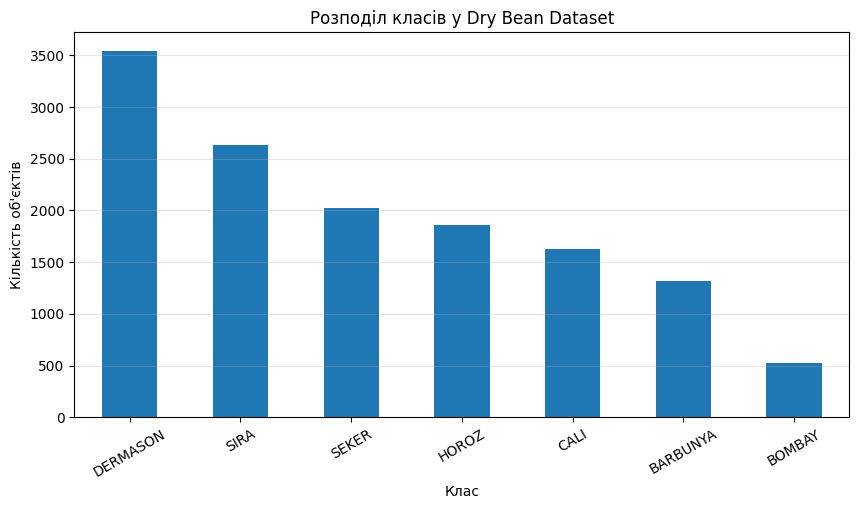

In [6]:
plt.figure(figsize=(10, 5))

df["Class"].value_counts().plot(kind="bar")

plt.xlabel("Клас")
plt.ylabel("Кількість об'єктів")
plt.title("Розподіл класів у Dry Bean Dataset")
plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)

plt.show()

### Кореляційний аналіз

In [7]:
if not np.issubdtype(df["Class"].dtype, np.number):

    class_mapping = {
        "SEKER": 0,
        "BARBUNYA": 1,
        "BOMBAY": 2,
        "CALI": 3,
        "DERMASON": 4,
        "HOROZ": 5,
        "SIRA": 6
    }

    df["Class_numeric"] = df["Class"].map(class_mapping)

else:
    df["Class_numeric"] = df["Class"]

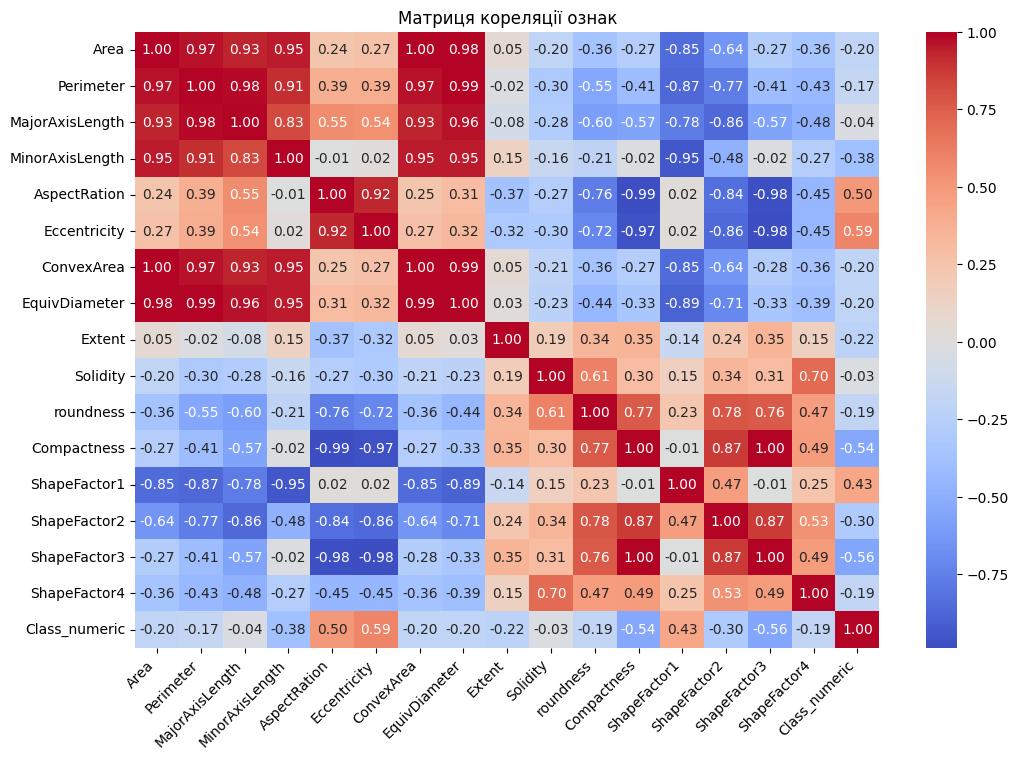

In [8]:
correlation_matrix = df.drop(columns=["Class"] ).corr()

plt.figure(figsize=(12, 8))
sns.heatmap( correlation_matrix, annot = True, fmt = ".2f", cmap = "coolwarm", center=0)
plt.title("Матриця кореляції ознак")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.show()

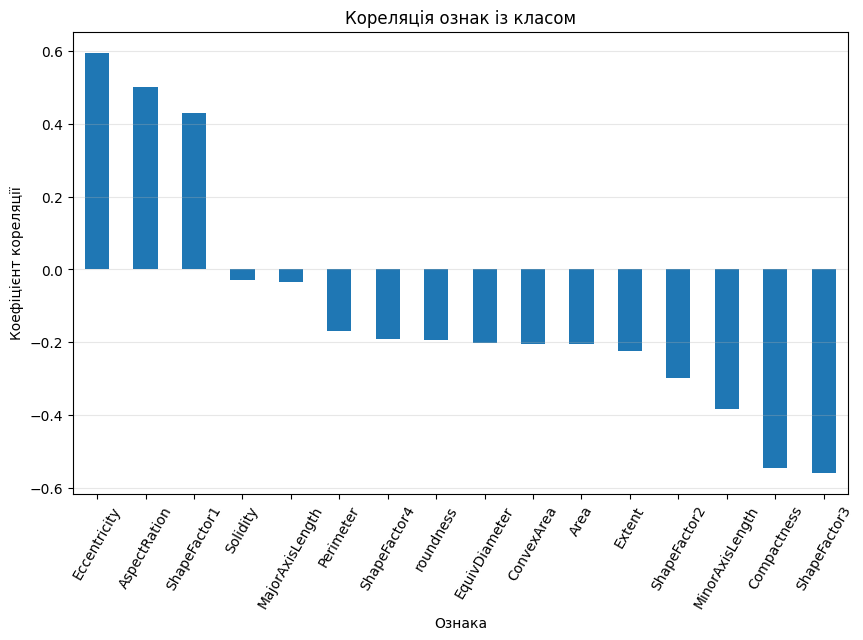

In [9]:
class_correlation = df.drop(columns=["Class"]).corr()["Class_numeric"].sort_values(ascending=False)

plt.figure(figsize=(10, 6))
class_correlation.drop("Class_numeric").plot(kind="bar") 
plt.xlabel("Ознака")
plt.ylabel("Коефіцієнт кореляції")
plt.title("Кореляція ознак із класом")
plt.xticks(rotation=60)
plt.grid(axis="y", alpha=0.3)
plt.show()

### Візуалізація залежності ознак від класу

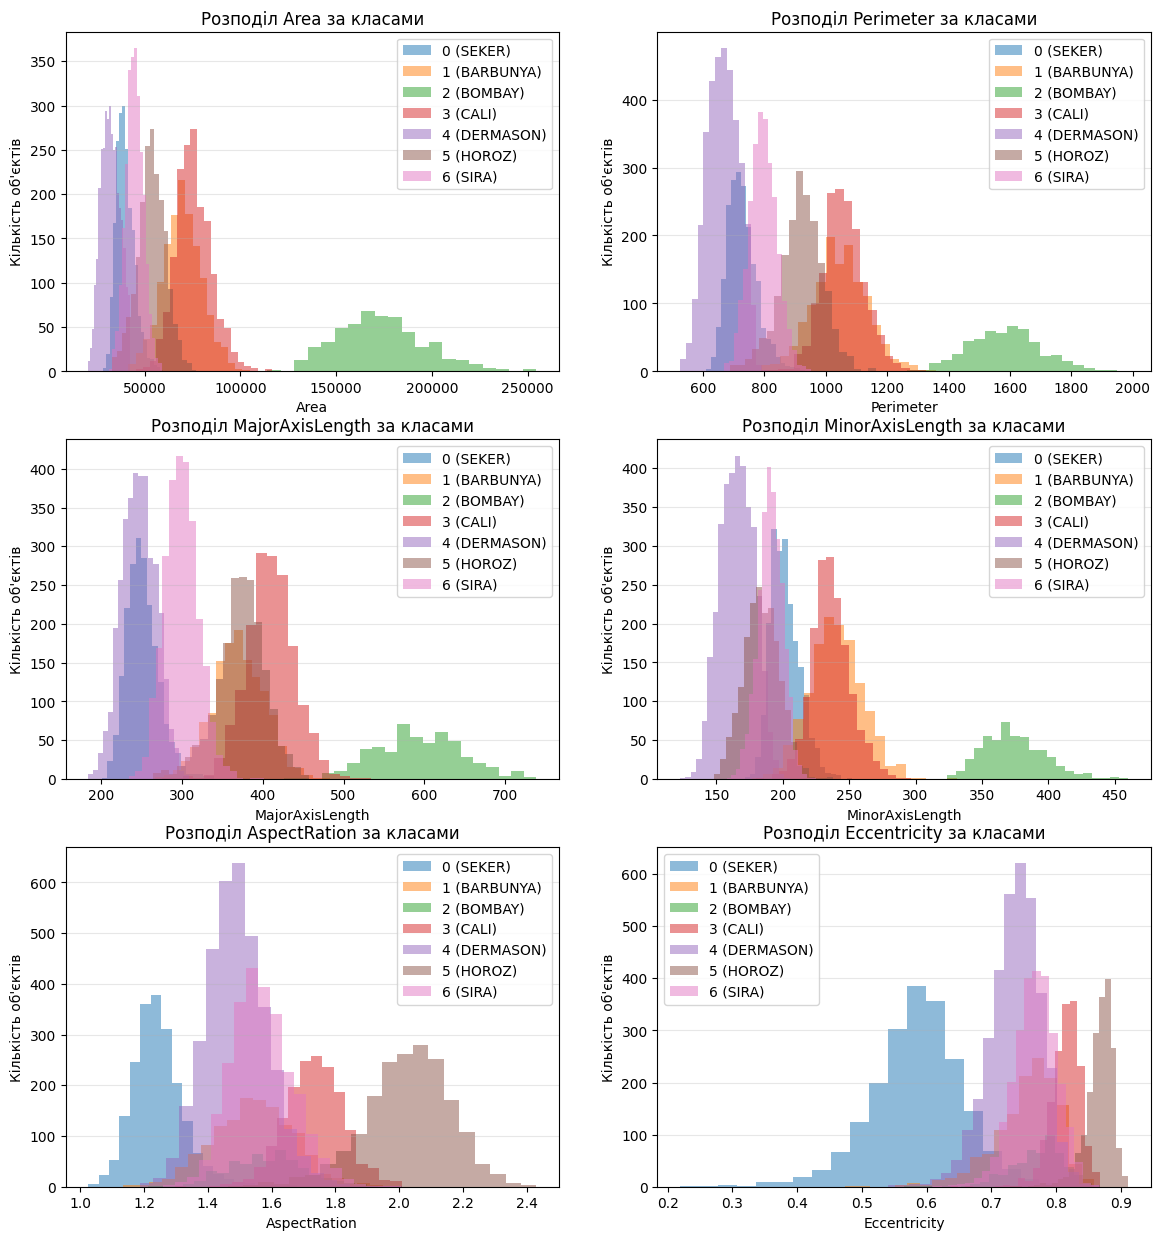

In [10]:
features_to_plot = ["Area", "Perimeter", "MajorAxisLength", "MinorAxisLength", "AspectRation", "Eccentricity"]
class_mapping = {0: "SEKER", 1: "BARBUNYA", 2: "BOMBAY", 3: "CALI", 4: "DERMASON", 5: "HOROZ", 6: "SIRA"}

fig, axes = plt.subplots(3, 2, figsize=(14, 15))

for ax, feature in zip(axes.ravel(), features_to_plot):

    for class_number, class_name in class_mapping.items():

        ax.hist(df[df["Class_numeric"] == class_number][feature], bins=20, alpha=0.5, label=f"{class_number} ({class_name})")

    ax.set_xlabel(feature)
    ax.set_ylabel("Кількість об'єктів")
    ax.set_title(f"Розподіл {feature} за класами")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)

plt.show()

### Підготовка X та y

In [11]:
X = df.drop(columns=["Class", "Class_numeric"]).values

y = df["Class_numeric"].values

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (13543, 16)
y shape: (13543,)


### Розділення даних на навчальну та тестову вибірки

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Навчальна вибірка:", X_train.shape)
print("Тестова вибірка:", X_test.shape)

Навчальна вибірка: (9480, 16)
Тестова вибірка: (4063, 16)


### Стандартизація ознак

In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Функція RBF-ядра

In [14]:
def rbf_kernel(X1, X2, gamma=0.01):
    
    X1_squared = np.sum(X1 ** 2, axis=1).reshape(-1, 1)
    X2_squared = np.sum(X2 ** 2, axis=1).reshape(1, -1)
    distances = X1_squared + X2_squared - 2 * X1 @ X2.T
    distances = np.maximum(distances, 0)
    
    return np.exp(-gamma * distances)

## **2. Власна реалізація Kernel SVM**

In [ ]:
class MyKernelSVM:

    def __init__(self, C=1.0, gamma=0.01, max_iter=1000, tol=1e-3):

        # Set model parameters
        self.C = C
        self.gamma = gamma
        self.max_iter = max_iter
        self.tol = tol

        # Store binary models
        self.models = []

        # Store class labels
        self.classes = None

    def _kernel(self, X1, X2):

        # Calculate RBF kernel
        return rbf_kernel(X1, X2, self.gamma)

    def _fit_binary(self, X, y):

        # Get number of samples
        n_samples = X.shape[0]

        # Calculate the kernel matrix
        K = self._kernel(X, X)

        # Start alpha values with zeros
        alpha = np.zeros(n_samples)

        # Start bias with zero
        b = 0.0

        # Calculate initial errors
        errors = -y.astype(float)

        # Repeat optimization
        for iteration in range(self.max_iter):

            # Count changed values
            changed = 0

            # Check each sample
            for i in range(n_samples):

                # Get error for sample i
                Ei = errors[i]

                # Check if alpha should be changed
                if not (
                    (y[i] * Ei < -self.tol and alpha[i] < self.C)
                    or
                    (y[i] * Ei > self.tol and alpha[i] > 0)
                ):
                    continue

                # Choose another random sample
                j = np.random.randint(0, n_samples - 1)

                # Make sure j is not i
                if j >= i:
                    j += 1

                # Get error for sample j
                Ej = errors[j]

                # Save old alpha values
                old_alpha_i = alpha[i]
                old_alpha_j = alpha[j]

                # Save old bias
                old_b = b

                # Calculate alpha limits
                if y[i] != y[j]:
                    L = max(0, alpha[j] - alpha[i])
                    H = min(self.C, self.C + alpha[j] - alpha[i])

                else:
                    L = max(0, alpha[i] + alpha[j] - self.C)
                    H = min(self.C, alpha[i] + alpha[j])

                # Skip if limits are equal
                if L == H:
                    continue

                # Calculate eta
                eta = 2 * K[i, j] - K[i, i] - K[j, j]

                # Skip if eta is not valid
                if eta >= -1e-8:
                    continue

                # Update alpha for sample j
                alpha[j] -= y[j] * (Ei - Ej) / eta

                # Keep alpha in the allowed range
                alpha[j] = np.clip(alpha[j], L, H)

                # Skip if alpha did not change enough
                if abs(alpha[j] - old_alpha_j) < 1e-5:
                    continue

                # Update alpha for sample i
                alpha[i] += y[i] * y[j] * (old_alpha_j - alpha[j])

                # Keep alpha in the allowed range
                alpha[i] = np.clip(alpha[i], 0, self.C)

                # Calculate changes in alpha
                delta_i = alpha[i] - old_alpha_i
                delta_j = alpha[j] - old_alpha_j

                # Calculate first bias value
                b1 = (
                    old_b
                    - Ei
                    - y[i] * delta_i * K[i, i]
                    - y[j] * delta_j * K[i, j]
                )

                # Calculate second bias value
                b2 = (
                    old_b
                    - Ej
                    - y[i] * delta_i * K[i, j]
                    - y[j] * delta_j * K[j, j]
                )

                # Choose the new bias
                if 0 < alpha[i] < self.C:
                    b = b1

                elif 0 < alpha[j] < self.C:
                    b = b2

                else:
                    b = (b1 + b2) / 2

                # Update errors
                errors += (
                    y[i] * delta_i * K[:, i]
                    + y[j] * delta_j * K[:, j]
                    + (b - old_b)
                )

                # Count the change
                changed += 1

            # Stop if there were no changes
            if changed == 0:
                break

        # Find support vectors
        support_indices = alpha > 1e-5

        # Save support vectors and model values
        return {
            "X": X[support_indices],
            "y": y[support_indices],
            "alpha": alpha[support_indices],
            "b": b
        }

    def fit(self, X, y):

        # Get unique classes
        self.classes = np.unique(y)

        # Clear old models
        self.models = []

        # Train one model for each class
        for class_value in self.classes:

            # Convert labels to 1 and -1
            y_binary = np.where(
                y == class_value,
                1,
                -1
            )

            # Train a binary model
            model = self._fit_binary(X, y_binary)

            # Save the model
            self.models.append(model)

        # Return the trained model
        return self

    def _decision_function(self, X, model):

        # Calculate kernel values
        K = self._kernel(X, model["X"])

        # Calculate prediction score
        return K @ (
            model["alpha"] * model["y"]
        ) + model["b"]

    def predict(self, X):

        # Store scores for all models
        scores = []

        # Get score from each model
        for model in self.models:

            # Calculate model score
            scores.append(
                self._decision_function(X, model)
            )

        # Convert scores to an array
        scores = np.array(scores).T

        # Choose the class with the highest score
        return self.classes[
            np.argmax(scores, axis=1)
        ]

In [16]:
my_svm = MyKernelSVM(C=1.0, gamma=0.01, max_iter=1000)

start_time = time()
my_svm.fit(X_train_scaled, y_train)
my_svm_runtime = time() - start_time

y_train_pred_my_svm = my_svm.predict(X_train_scaled)
y_test_pred_my_svm = my_svm.predict(X_test_scaled)

my_svm_train_accuracy = accuracy_score(y_train, y_train_pred_my_svm)
my_svm_test_accuracy = accuracy_score(y_test, y_test_pred_my_svm)

print("Train Accuracy:", my_svm_train_accuracy)
print("Test Accuracy:", my_svm_test_accuracy)
print("Time:", my_svm_runtime)

Train Accuracy: 0.9184599156118144
Test Accuracy: 0.9170563622938716
Time: 67.35182452201843


## **3. Реалізація за допомогою Scikit-learn SVM**

In [17]:
sklearn_svm = SVC(kernel="rbf", C=1.0, gamma=0.01)

start_time = time()
sklearn_svm.fit(X_train_scaled, y_train)
sklearn_svm_runtime = time() - start_time

y_train_pred_sklearn_svm = sklearn_svm.predict(X_train_scaled)
y_test_pred_sklearn_svm = sklearn_svm.predict(X_test_scaled)

sklearn_svm_train_accuracy = accuracy_score(y_train, y_train_pred_sklearn_svm)
sklearn_svm_test_accuracy = accuracy_score(y_test, y_test_pred_sklearn_svm)

print("Train Accuracy:", sklearn_svm_train_accuracy)
print("Test Accuracy:", sklearn_svm_test_accuracy)
print("Time:", sklearn_svm_runtime)

Train Accuracy: 0.9260548523206751
Test Accuracy: 0.924193945360571
Time: 1.0155887603759766


## **4. Порівняння**

In [18]:
svm_results = pd.DataFrame({
    "Model": ["My Kernel SVM", "Scikit-learn SVM"],
    "Train Accuracy": [my_svm_train_accuracy, sklearn_svm_train_accuracy],
    "Test Accuracy": [my_svm_test_accuracy, sklearn_svm_test_accuracy],
    "Time": [my_svm_runtime, sklearn_svm_runtime]
})

svm_results

,Model,Train Accuracy,Test Accuracy,Time
0,My Kernel SVM,0.918460,0.917056,67.351825
1,Scikit-learn SVM,0.926055,0.924194,1.015589


### Порівняння точності SVM

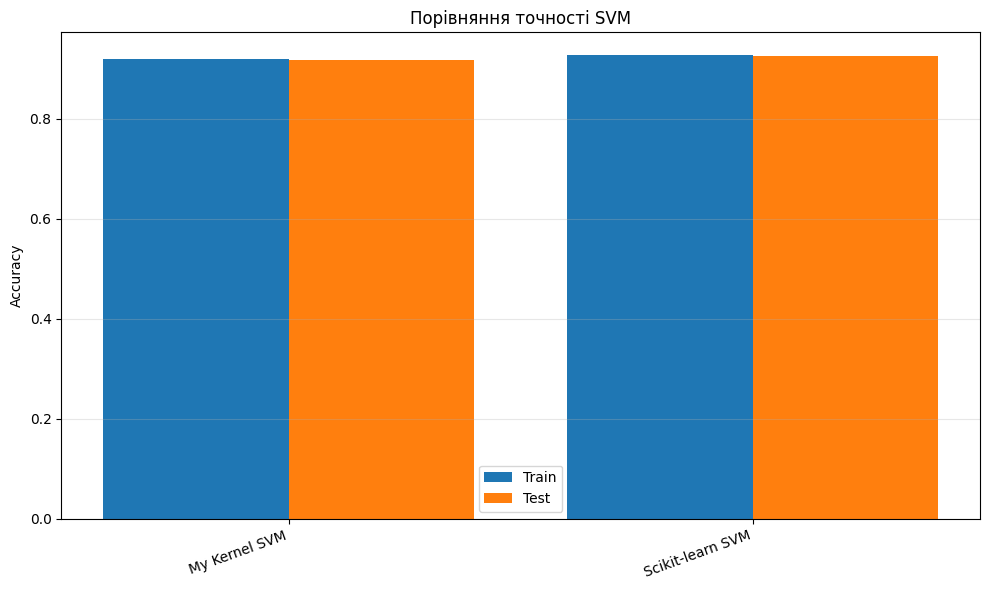

In [19]:
x = np.arange(2)

plt.figure(figsize=(10, 6))
plt.bar(x - 0.2, [my_svm_train_accuracy, sklearn_svm_train_accuracy], 0.4, label="Train")
plt.bar(x + 0.2, [my_svm_test_accuracy, sklearn_svm_test_accuracy], 0.4, label="Test")
plt.xticks(x, ["My Kernel SVM", "Scikit-learn SVM"], rotation=20, ha="right")
plt.ylabel("Accuracy")
plt.title("Порівняння точності SVM")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Порівняння матриць помилок SVM

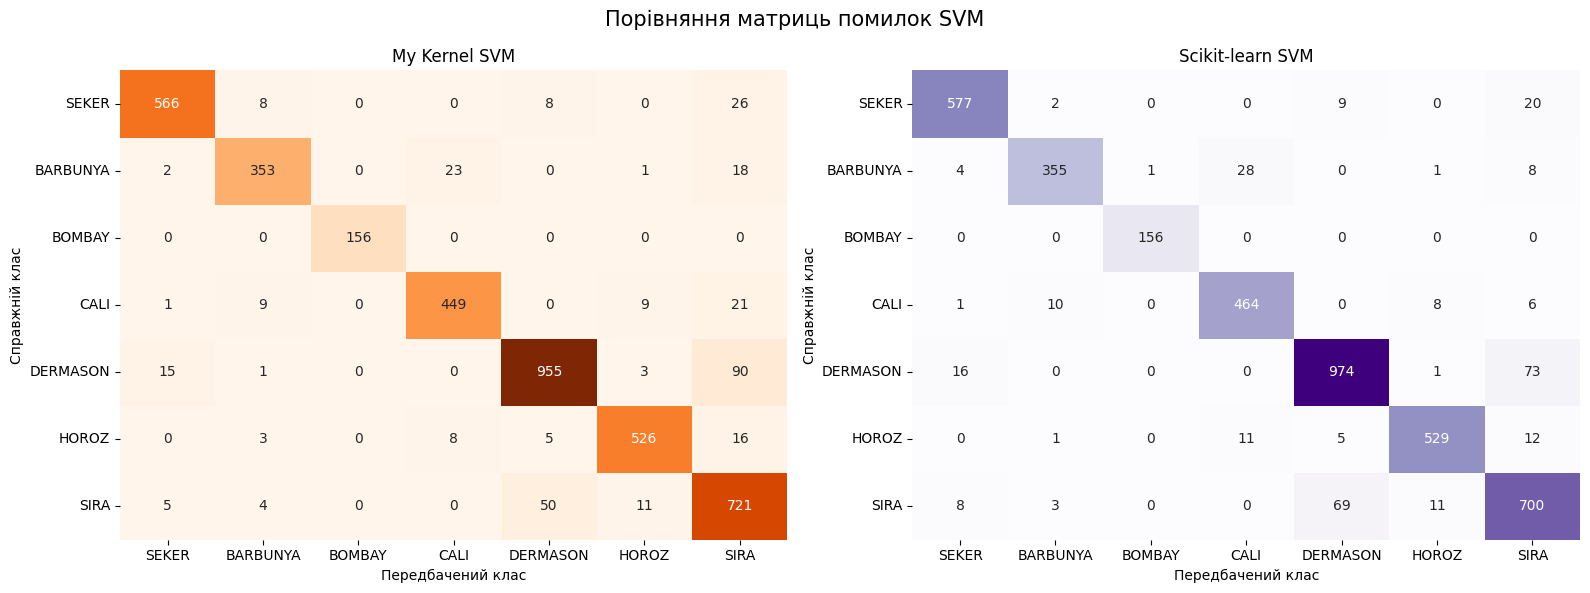

In [20]:
class_names = ["SEKER", "BARBUNYA", "BOMBAY", "CALI", "DERMASON", "HOROZ", "SIRA"]

cm_my_svm = confusion_matrix(y_test, y_test_pred_my_svm)
cm_sklearn_svm = confusion_matrix(y_test, y_test_pred_sklearn_svm)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm_my_svm, annot=True, fmt="d", cmap="Oranges", xticklabels=class_names, yticklabels=class_names, ax=axes[0], cbar=False)
axes[0].set_title("My Kernel SVM")
axes[0].set_xlabel("Передбачений клас")
axes[0].set_ylabel("Справжній клас")

sns.heatmap(cm_sklearn_svm, annot=True, fmt="d", cmap="Purples", xticklabels=class_names, yticklabels=class_names, ax=axes[1], cbar=False)
axes[1].set_title("Scikit-learn SVM")
axes[1].set_xlabel("Передбачений клас")
axes[1].set_ylabel("Справжній клас")

plt.suptitle("Порівняння матриць помилок SVM", fontsize=15)
plt.tight_layout()
plt.show()

### Порівняння часу навчання SVM

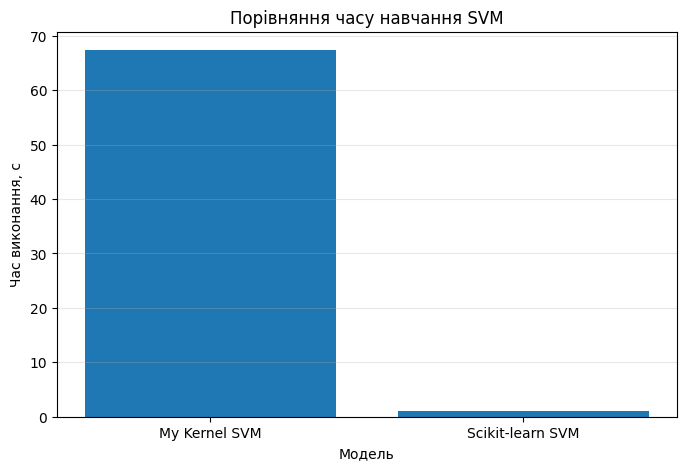

In [21]:
plt.figure(figsize=(8, 5))

plt.bar(
    svm_results["Model"],
    svm_results["Time"]
)

plt.ylabel("Час виконання, с")
plt.xlabel("Модель")
plt.title("Порівняння часу навчання SVM")
plt.grid(axis="y", alpha=0.3)

plt.show()